In [1]:
from experiments_pretrained import *
from router_injection import *

/home/dylan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Set seeds
seed = 42
np.random.seed(seed);
torch.manual_seed(seed);

In [3]:
model_choice = 'deepseek'

# Get model (with attached MoE monitoring probe and router injector) and tokenizer
# Be sure to attach router injector mixin before probe mixin, otherwise probe will not see injector updates
if model_choice == "qwen":
    model, tokenizer = load_model_qwen()
    router_injector = MoERouterInjectorQwen(model)
    probe = MoEProbeQwen(model)
    
elif model_choice == "deepseek":
    model, tokenizer = load_model_deepseek()
    
    router_injector = MoERouterInjectorDeepSeek(model)
    probe = MoEProbeDeepSeek(model)
    
    
elif model_choice == "mistral":
    model, tokenizer = load_model_mistral()
    router_injector = MoERouterInjectorMistral(model)
    probe = MoEProbeMistral(model)
else:
    raise ValueError("Invalid model_choice. Select 'qwen', 'deepseek', or 'mistral'.")

`rope_scaling`'s factor field must be a float >= 1, got 40
`rope_scaling`'s beta_fast field must be a float, got 32
`rope_scaling`'s beta_slow field must be a float, got 1


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

MoEHook: Scanning model for routers...
MoEHook: Attached probes to 26 router layers.
MoEHook: Model has 26 routers each with 64 experts and selects k=6 at each layer.
MoEHook: Scanning model for routers...
MoEHook: Attached probes to 26 router layers.
MoEHook: Model has 26 routers each with 64 experts and selects k=6 at each layer.


In [7]:
# Set router distribution
# DeepSeek router outputs: tuple of topk indices and logits
# each of size [batch, k]

n_experts = router_injector.get_n_experts()
n_routers = router_injector.get_n_routers()
k = router_injector.get_k()

n_forced_routers = 3
selected_routers = list(range(n_forced_routers))
forced_experts = [0, 1, 2, 3, 4, 5]

forced_topk_indices = torch.tensor(forced_experts)
forced_router_logits = torch.ones(k) * 1/n_experts
forced_outputs = (forced_topk_indices, forced_router_logits)

for i in selected_routers:
    router_injector.set_router_outputs(i, forced_outputs)

In [8]:
prompt = "Explain in detail the political system of the People's Republic of China."

# Start timing
start_time = time.time()
    
# Generate response and get metrics
response, probs, active_experts = single_generate(model, tokenizer, probe,
                                                  prompt=prompt, max_new_tokens=100)

# Stop timing
end_time = time.time()
inference_time = end_time - start_time
print(f"Inference took {inference_time:.3f}s.")

print(response)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:100001 for open-end generation.


Inference took 19.818s.
 China’s foreign minister, Li Qingguo, who is a former senior official at the Chinese Embassy in London, said that China’s foreign minister, Li Qingguo, said that China’s foreign minister, Li Qingguo, said that China’s foreign minister, Li Qingguo, said that China’s foreign minister, Li Qingguo, said that China’s foreign minister, Li Qingguo, said that China’s foreign minister, Li Qinggu


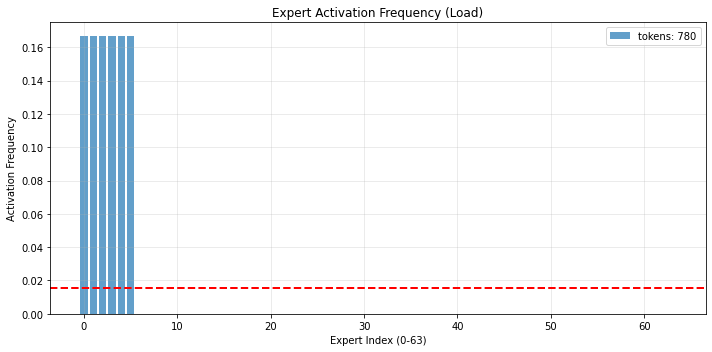

In [9]:
probe.plot_loadbalance(router_id=selected_routers[0])